In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
RUNS_DIR = Path.cwd().parent / "runs"

data = pd.read_csv(RUNS_DIR / "__old" / "sweep-dncnn-256x256" / "baseline.csv")
baseline_sizes = np.array([int(x.split("x")[0]) for x in data["dataset"] if x != "all-avg"])
baseline_losses = data.loc[data["dataset"] != "all-avg"]["value"].to_numpy()

run_paths = [
    RUNS_DIR / "__old" / "sweep-classic-64x64",
    RUNS_DIR / "__old" / "sweep-classic-128x128",
    RUNS_DIR / "__old" / "sweep-classic-256x256",
    RUNS_DIR / "__old" / "sweep-classic-mixed",
    RUNS_DIR / "__old" / "sweep-dncnn-64x64",
    RUNS_DIR / "__old" / "sweep-dncnn-128x128",
    RUNS_DIR / "__old" / "sweep-dncnn-256x256",
    RUNS_DIR / "__old" / "sweep-dncnn-mixed",
    RUNS_DIR / "__old" / "sweep-interp-64x64",
    RUNS_DIR / "__old" / "sweep-interp-128x128",
    RUNS_DIR / "__old" / "sweep-interp-256x256",
    RUNS_DIR / "__old" / "sweep-interp-mixed",
    RUNS_DIR / "heat-64x64",
    RUNS_DIR / "heat-128x128",
    RUNS_DIR / "heat-256x256",
    RUNS_DIR / "heat-mixed",
]

sweep-classic-64x64:       80x80
sweep-classic-128x128:    144x144
sweep-classic-256x256:    256x256
sweep-classic-mixed:      240x240
sweep-dncnn-64x64:         80x80
sweep-dncnn-128x128:      128x128
sweep-dncnn-256x256:      176x176
sweep-dncnn-mixed:        128x128
sweep-interp-64x64:       128x128
sweep-interp-128x128:     128x128
sweep-interp-256x256:      64x64
sweep-interp-mixed:        64x64
heat-64x64:                64x64
heat-128x128:             128x128
heat-256x256:             256x256
heat-mixed:               304x304


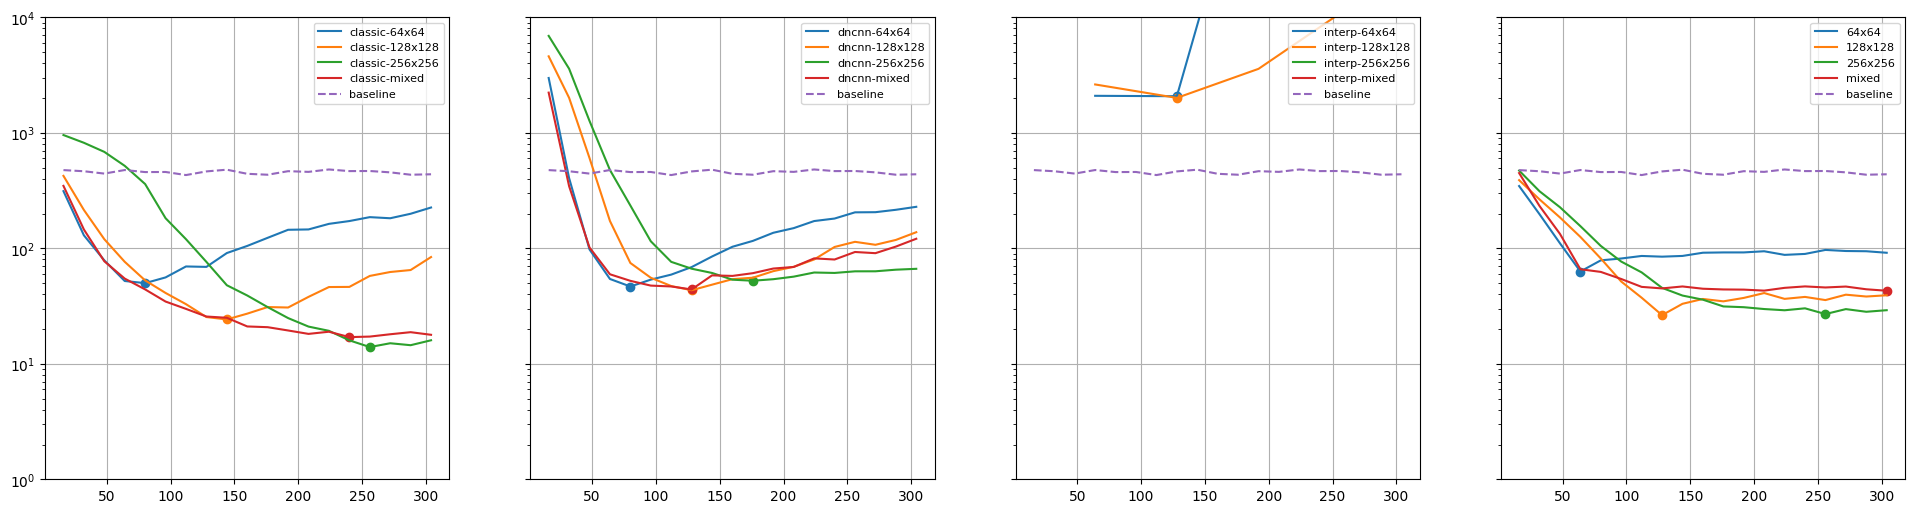

In [23]:
plt.subplots(1, 4, figsize=(24, 6), sharey=True)
plt.ylim(1e0, 1e4)
for part in ["classic", "dncnn", "interp", "heat"]:
    plt.subplot(1, 4, ["classic", "dncnn", "interp", "heat"].index(part) + 1)
    for run_path in run_paths:
        if part not in run_path.name:
            continue
        data = pd.read_csv(run_path / "test-results.csv")
        sizes = np.array([int(x.split("x")[0]) for x in data["dataset"] if x != "all-avg"])
        data.rename(columns={" value": "value"}, inplace=True)
        losses = data.loc[data["dataset"] != "all-avg"]["value"].to_numpy()
        plt.plot(sizes, losses, label="-".join(run_path.name.split("-")[1:]))
        best_i = np.argmin(losses)
        plt.scatter(sizes[best_i], losses[best_i])
        print(f"{run_path.name+':':25} {sizes[best_i]: >3d}x{sizes[best_i]}")
    plt.plot(baseline_sizes, baseline_losses, "--", label="baseline")
    plt.yscale("log")
    plt.legend(fontsize=8, loc="upper right")
    plt.scatter([i for i in range(300)], [float("NaN") for _ in range(300)])
    plt.grid()
plt.show()